# Player Performance Deep Dive (v3 — No Goalkeepers)

Granular analysis of every player-performance column, grouped and reviewed **by position**.

**Input:** `within_league_transfers_v3.parquet` (no goalkeepers)  
**Positions:** Central Defender, Full Back, Midfielder, Winger, Striker

## Metric groups

| # | Group | Prefix pattern | Description |
|---|-------|---------------|-------------|
| 1 | **Twelve Quality Scores** | 20 named composites | Composite metrics computed by Twelve Football from z-scores |
| 2 | **Other quality / ratio metrics** | `from_*` quality & ratio cols not in group 1 | Wyscout-derived quality scores (Aerials won %, Shot conversion %, etc.) |
| 3 | **Per-90 counting stats** | `from_*_per_90` | Raw event counts normalised to 90 minutes |
| 4 | **Position-adjusted z-scores** | `from_z_score_*` | Z-scores within position groups |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=0.85)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.3f}".format)

DATA_PATH = "../../../thesis_data/processed_data/thesis_model_dataset/within_league_transfers_v3.parquet"
df = pd.read_parquet(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nPositions:")
print(df["from_position"].value_counts().to_string())

Shape: 18,065 rows x 512 columns

Positions:
from_position
Midfielder          5230
Central Defender    4766
Full Back           3812
Striker             2422
Winger              1835


## 1. Define metric groups

In [2]:
# --- Twelve Quality Scores (20 metrics, computed by Twelve Football) ---
TWELVE_QS_NAMES = [
    "Active defence", "Aerial threat", "Box threat", "Chance prevention",
    "Composure", "Defensive heading", "Dribbling", "Effectiveness",
    "Finishing", "Hold-up play", "Intelligent defence", "Involvement",
    "Passing quality", "Poaching", "Pressing", "Progression",
    "Providing teammates", "Run quality", "Territorial dominance", "Winning duels",
]

from_twelve_qs = [f"from_{n}" for n in TWELVE_QS_NAMES]
to_twelve_qs   = [f"to_{n}" for n in TWELVE_QS_NAMES]

# Verify they exist
missing_from = [c for c in from_twelve_qs if c not in df.columns]
missing_to   = [c for c in to_twelve_qs if c not in df.columns]
print(f"Twelve QS (from): {len(from_twelve_qs)} cols, missing: {missing_from}")
print(f"Twelve QS (to):   {len(to_twelve_qs)} cols, missing: {missing_to}")

Twelve QS (from): 20 cols, missing: []
Twelve QS (to):   20 cols, missing: []


In [3]:
# --- Build remaining groups from column names ---
all_cols = df.columns.tolist()

# Structural / ID columns (not performance)
STRUCTURAL = [
    "wy_player_id", "wyscout_height", "wyscout_weight", "player_season_age",
    "tm_transfer_value", "tm_transfer_fee",
    "from_Minutes", "from_competition", "from_position", "from_season", "from_team_id",
    "to_Minutes", "to_competition", "to_position", "to_season", "to_team_id",
    "from_comp_division", "from_comp_season_id", "from_comp_season_name",
    "to_comp_division", "to_comp_season_id", "to_comp_season_name",
]

# Team stats (separate analysis later)
from_team_stats = [c for c in all_cols if c.startswith("from_team_stats_")]
to_team_stats   = [c for c in all_cols if c.startswith("to_team_stats_")]

# Z-scores
from_zscores = sorted([c for c in all_cols if c.startswith("from_z_score_")])
to_zscores   = sorted([c for c in all_cols if c.startswith("to_z_score_")])

# Per-90 stats
from_per90 = sorted([c for c in all_cols if c.startswith("from_") and c.endswith("_per_90")])
to_per90   = sorted([c for c in all_cols if c.startswith("to_") and c.endswith("_per_90")])

# Other quality / ratio metrics = from_ columns that are NOT structural, NOT twelve QS,
# NOT per_90, NOT z_score, NOT team_stats
exclude_from = set(STRUCTURAL + from_twelve_qs + from_per90 + from_zscores + from_team_stats)
from_other_quality = sorted([c for c in all_cols if c.startswith("from_") and c not in exclude_from])

exclude_to = set(STRUCTURAL + to_twelve_qs + to_per90 + to_zscores + to_team_stats)
to_other_quality = sorted([c for c in all_cols if c.startswith("to_") and c not in exclude_to])

print(f"Twelve Quality Scores (from/to): {len(from_twelve_qs)} / {len(to_twelve_qs)}")
print(f"Other quality/ratio   (from/to): {len(from_other_quality)} / {len(to_other_quality)}")
print(f"Per-90 stats          (from/to): {len(from_per90)} / {len(to_per90)}")
print(f"Z-scores              (from/to): {len(from_zscores)} / {len(to_zscores)}")
print(f"Team stats            (from/to): {len(from_team_stats)} / {len(to_team_stats)}")
print(f"Structural:                      {len(STRUCTURAL)}")

accounted = (len(STRUCTURAL) + len(from_twelve_qs) + len(to_twelve_qs)
             + len(from_other_quality) + len(to_other_quality)
             + len(from_per90) + len(to_per90)
             + len(from_zscores) + len(to_zscores)
             + len(from_team_stats) + len(to_team_stats))
print(f"\nAccounted: {accounted} / {len(all_cols)} columns")
unaccounted = [c for c in all_cols if c not in set(
    STRUCTURAL + from_twelve_qs + to_twelve_qs + from_other_quality + to_other_quality
    + from_per90 + to_per90 + from_zscores + to_zscores + from_team_stats + to_team_stats
)]
if unaccounted:
    print(f"Unaccounted columns: {unaccounted}")

Twelve Quality Scores (from/to): 20 / 20
Other quality/ratio   (from/to): 76 / 76
Per-90 stats          (from/to): 0 / 0
Z-scores              (from/to): 75 / 75
Team stats            (from/to): 74 / 74
Structural:                      22

Accounted: 512 / 512 columns


---
## 2. Twelve Quality Scores — `from_` side

These 20 metrics are **composite scores computed by Twelve Football** from position-adjusted z-scores.  
They represent high-level player abilities (e.g., *Finishing*, *Pressing*, *Dribbling*).

In [4]:
# 2a. Null counts by position — Twelve Quality Scores (from)
positions = df["from_position"].unique().tolist()
positions.sort()

null_tqs = pd.DataFrame(index=from_twelve_qs, columns=positions)
for pos in positions:
    mask = df["from_position"] == pos
    n = mask.sum()
    null_tqs[pos] = df.loc[mask, from_twelve_qs].isnull().sum().apply(lambda x: f"{x} ({100*x/n:.1f}%)")

null_tqs["TOTAL"] = df[from_twelve_qs].isnull().sum().apply(
    lambda x: f"{x} ({100*x/len(df):.1f}%)")

print("Null counts — Twelve Quality Scores (from side)")
null_tqs

Null counts — Twelve Quality Scores (from side)


,Central Defender,Full Back,Midfielder,Striker,Winger,TOTAL
from_Active defence,1 (0.0%),0 (0.0%),0 (0.0%),77 (3.2%),2 (0.1%),80 (0.4%)
from_Aerial threat,3 (0.1%),33 (0.9%),8 (0.2%),1 (0.0%),1 (0.1%),46 (0.3%)
from_Box threat,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)
from_Chance prevention,0 (0.0%),0 (0.0%),5230 (100.0%),2422 (100.0%),1835 (100.0%),9487 (52.5%)
from_Composure,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)
from_Defensive heading,0 (0.0%),0 (0.0%),2 (0.0%),5 (0.2%),7 (0.4%),14 (0.1%)
from_Dribbling,119 (2.5%),0 (0.0%),1 (0.0%),1 (0.0%),0 (0.0%),121 (0.7%)
from_Effectiveness,71 (1.5%),37 (1.0%),15 (0.3%),38 (1.6%),0 (0.0%),161 (0.9%)
from_Finishing,71 (1.5%),37 (1.0%),15 (0.3%),1 (0.0%),0 (0.0%),124 (0.7%)
from_Hold-up play,1104 (23.2%),32 (0.8%),0 (0.0%),1 (0.0%),0 (0.0%),1137 (6.3%)


In [5]:
# 2b. Descriptive stats — Twelve Quality Scores (from)
df[from_twelve_qs].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
from_Active defence,17985.000,0.048,0.674,-2.394,-0.419,0.031,0.498,3.532
from_Aerial threat,18019.000,0.067,0.665,-2.333,-0.365,0.068,0.484,3.537
from_Box threat,18064.000,0.011,0.664,-1.635,-0.490,-0.097,0.398,4.059
from_Chance prevention,8578.000,-0.156,0.587,-2.994,-0.531,-0.121,0.254,1.933
from_Composure,18064.000,0.027,0.558,-2.273,-0.344,0.019,0.390,3.058
from_Defensive heading,18051.000,0.080,0.784,-2.838,-0.461,0.063,0.600,3.980
from_Dribbling,17944.000,0.003,0.578,-2.029,-0.364,-0.070,0.289,3.950
from_Effectiveness,17904.000,-0.014,0.362,-1.220,-0.265,-0.044,0.205,1.899
from_Finishing,17941.000,0.004,0.735,-2.297,-0.530,-0.173,0.426,4.244
from_Hold-up play,16928.000,0.031,0.445,-1.554,-0.268,0.011,0.311,3.209


In [6]:
# 2c. Stats by position — Twelve Quality Scores (from)
for pos in positions:
    sub = df.loc[df["from_position"] == pos, from_twelve_qs]
    print(f"\n{'='*80}")
    print(f"Position: {pos}  (n={len(sub):,})")
    print(sub.describe().T[["count","mean","std","min","25%","50%","75%","max"]].round(3).to_string())


Position: Central Defender  (n=4,766)
                              count   mean   std    min    25%    50%   75%   max
from_Active defence        4765.000  0.058 0.675 -2.261 -0.410  0.035 0.499 3.532
from_Aerial threat         4763.000  0.077 0.617 -2.333 -0.330  0.076 0.479 2.772
from_Box threat            4766.000  0.082 0.663 -1.307 -0.400 -0.017 0.486 3.588
from_Chance prevention     4766.000 -0.148 0.581 -2.914 -0.524 -0.115 0.257 1.933
from_Composure             4766.000 -0.030 0.584 -2.008 -0.416 -0.049 0.345 3.058
from_Defensive heading     4766.000  0.149 0.800 -2.838 -0.391  0.160 0.702 3.181
from_Dribbling             4647.000 -0.011 0.578 -1.722 -0.337 -0.083 0.221 3.638
from_Effectiveness         4695.000  0.010 0.364 -1.219 -0.240 -0.018 0.233 1.844
from_Finishing             4695.000  0.035 0.802 -1.997 -0.564 -0.205 0.515 4.244
from_Hold-up play          3662.000  0.015 0.460 -1.505 -0.299 -0.002 0.304 2.415
from_Intelligent defence   4766.000  0.059 0.604 -1.894 -0.

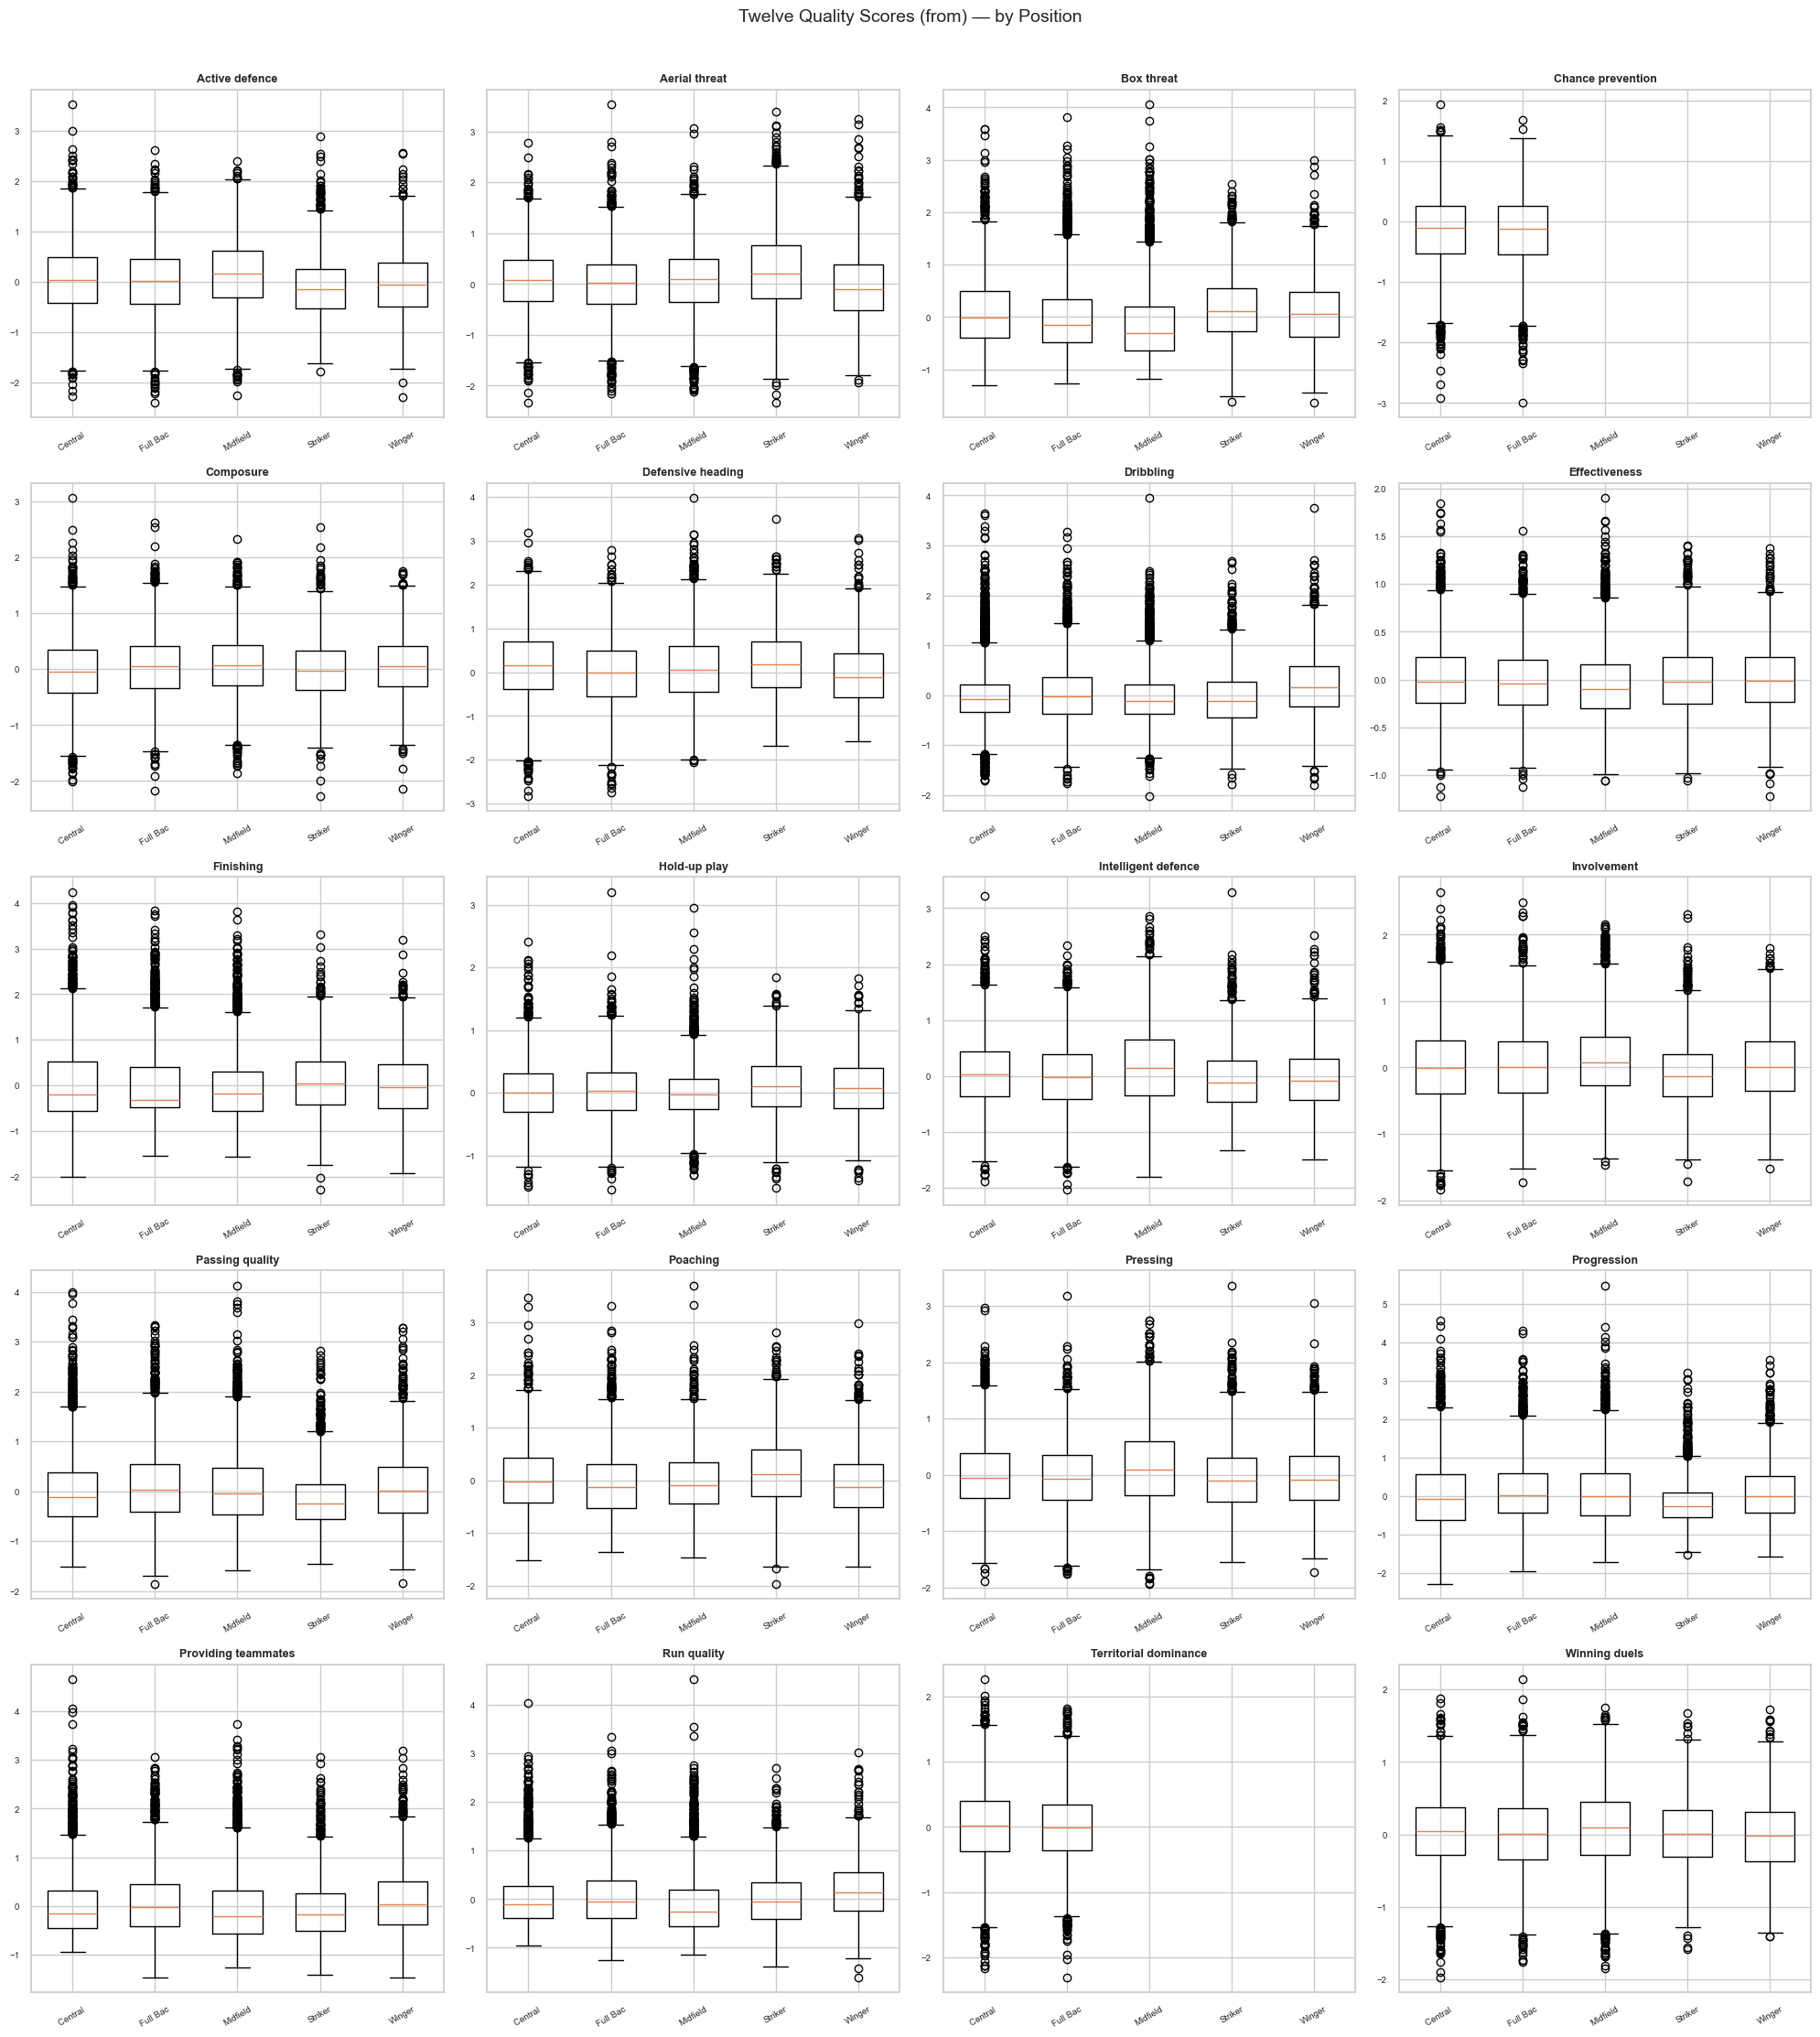

In [7]:
# 2d. Boxplots — Twelve Quality Scores by position (from)
fig, axes = plt.subplots(5, 4, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(from_twelve_qs):
    ax = axes[i]
    data_list = [df.loc[df["from_position"] == p, col].dropna() for p in positions]
    ax.boxplot(data_list, labels=[p[:8] for p in positions], widths=0.6)
    ax.set_title(col.replace("from_", ""), fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Twelve Quality Scores (from) — by Position", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Other Quality / Ratio Metrics — `from_` side

These are Wyscout-derived quality and ratio metrics (e.g., *Aerials won %*, *Shot conversion %*, *Goals - xG*).  
They are **not** computed by Twelve Football.

In [8]:
# 3a. List all other quality/ratio columns (from)
print(f"Other quality/ratio metrics (from): {len(from_other_quality)} columns\n")
for i, c in enumerate(from_other_quality, 1):
    print(f"  {i:2d}. {c}")

Other quality/ratio metrics (from): 76 columns

   1. from_Aerials per 90
   2. from_Aerials won %
   3. from_Aerials won per 90
   4. from_Assists per 90
   5. from_Attacking aerials won %
   6. from_Attacking aerials won per 90
   7. from_Ball progression (xT) per 90
   8. from_Ball recoveries per 90
   9. from_Ball runs (xT) per 90
  10. from_Box entries per 90
  11. from_Carries (xT) per 100 receptions
  12. from_Carries (xT) per 90
  13. from_Counterpressing per 90
  14. from_Creative passes per 90
  15. from_Crosses (xT) per 90
  16. from_Deep completions per 90
  17. from_Deep runs (xT) per 90
  18. from_Defending 1v1 %
  19. from_Defensive actions per 90
  20. from_Defensive aerials won %
  21. from_Defensive aerials won per 90
  22. from_Defensive area (m^2)
  23. from_Defensive duels won %
  24. from_Defensive duels won per 90
  25. from_Defensive intensity per 90
  26. from_Defensive line height (m)
  27. from_Dribbles (xT) per 90
  28. from_Dribbles success %
  29. from_Goa

In [9]:
# 3b. Null counts by position — Other quality metrics (from)
null_oq = pd.DataFrame(index=from_other_quality, columns=positions)
for pos in positions:
    mask = df["from_position"] == pos
    n = mask.sum()
    null_oq[pos] = df.loc[mask, from_other_quality].isnull().sum().apply(
        lambda x: f"{x} ({100*x/n:.1f}%)")

null_oq["TOTAL"] = df[from_other_quality].isnull().sum().apply(
    lambda x: f"{x} ({100*x/len(df):.1f}%)")

print("Null counts — Other quality/ratio metrics (from side)")
null_oq

Null counts — Other quality/ratio metrics (from side)


,Central Defender,Full Back,Midfielder,Striker,Winger,TOTAL
from_Aerials per 90,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
from_Aerials won %,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
from_Aerials won per 90,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
from_Assists per 90,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
from_Attacking aerials won %,3 (0.1%),33 (0.9%),8 (0.2%),0 (0.0%),1 (0.1%),45 (0.2%)
from_Attacking aerials won per 90,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
from_Ball progression (xT) per 90,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
from_Ball recoveries per 90,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
from_Ball runs (xT) per 90,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
from_Box entries per 90,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)


In [10]:
# 3c. Descriptive stats — Other quality metrics (from)
df[from_other_quality].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
from_Aerials per 90,18065.000,4.219,2.826,0.096,2.296,3.511,5.325,32.376
from_Aerials won %,18065.000,0.475,0.131,0.000,0.387,0.486,0.571,1.000
from_Aerials won per 90,18065.000,2.067,1.498,0.000,0.971,1.691,2.809,16.832
from_Assists per 90,18065.000,0.065,0.082,0.000,0.000,0.045,0.098,0.783
from_Attacking aerials won %,18020.000,0.568,0.192,0.000,0.444,0.565,0.692,1.000
from_Attacking aerials won per 90,18065.000,0.877,1.066,0.000,0.313,0.553,0.950,13.998
from_Ball progression (xT) per 90,18065.000,0.123,0.065,0.006,0.074,0.110,0.161,0.547
from_Ball recoveries per 90,18065.000,2.414,1.353,0.000,1.333,2.312,3.314,8.411
from_Ball runs (xT) per 90,18065.000,0.023,0.019,0.000,0.009,0.018,0.031,0.194
from_Box entries per 90,18065.000,0.276,0.374,0.000,0.000,0.146,0.378,4.108


In [11]:
# 3d. Stats by position — Other quality metrics (from)
for pos in positions:
    sub = df.loc[df["from_position"] == pos, from_other_quality]
    print(f"\n{'='*80}")
    print(f"Position: {pos}  (n={len(sub):,})")
    print(sub.describe().T[["count","mean","std","min","25%","50%","75%","max"]].round(3).to_string())


Position: Central Defender  (n=4,766)
                                                            count    mean     std     min     25%     50%     75%      max
from_Aerials per 90                                      4766.000   5.177   1.807   0.859   3.926   4.964   6.127   15.567
from_Aerials won %                                       4766.000   0.588   0.079   0.243   0.538   0.592   0.642    0.839
from_Aerials won per 90                                  4766.000   3.085   1.251   0.280   2.195   2.934   3.750   10.336
from_Assists per 90                                      4766.000   0.016   0.031   0.000   0.000   0.000   0.030    0.192
from_Attacking aerials won %                             4763.000   0.611   0.150   0.000   0.511   0.606   0.700    1.000
from_Attacking aerials won per 90                        4766.000   0.677   0.395   0.000   0.400   0.609   0.870    4.007
from_Ball progression (xT) per 90                        4766.000   0.087   0.035   0.010   0.062   

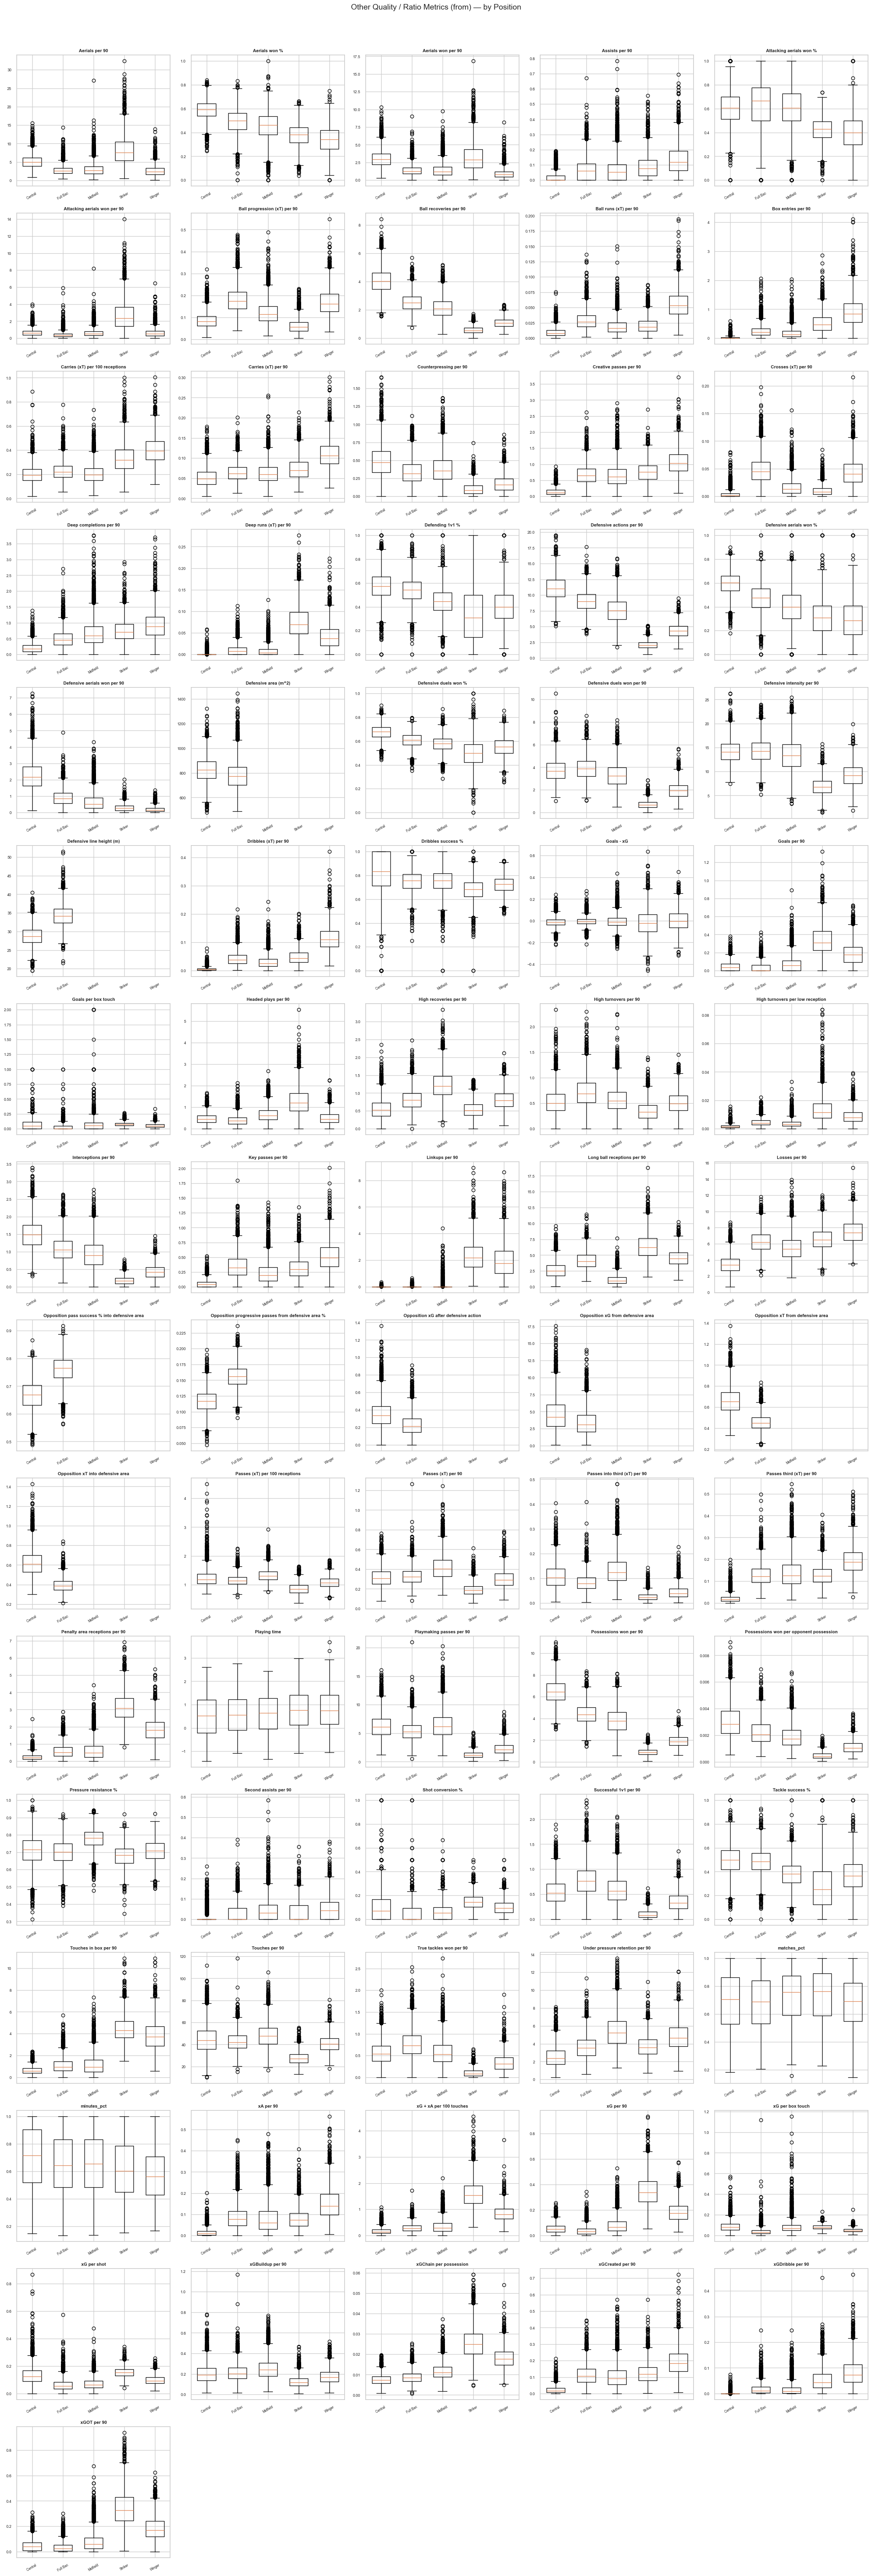

In [12]:
# 3e. Boxplots — Other quality metrics by position (from)
n_oq = len(from_other_quality)
ncols_plot = 5
nrows_plot = (n_oq + ncols_plot - 1) // ncols_plot

fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(22, 4 * nrows_plot))
axes = axes.flatten()

for i, col in enumerate(from_other_quality):
    ax = axes[i]
    data_list = [df.loc[df["from_position"] == p, col].dropna() for p in positions]
    ax.boxplot(data_list, labels=[p[:8] for p in positions], widths=0.6)
    ax.set_title(col.replace("from_", ""), fontsize=8, fontweight="bold")
    ax.tick_params(axis="x", labelsize=6, rotation=30)
    ax.tick_params(axis="y", labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Other Quality / Ratio Metrics (from) — by Position", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Per-90 Counting Stats — `from_` side

Raw event counts normalised to 90 minutes played.

In [13]:
# 4a. List per-90 columns (from)
print(f"Per-90 metrics (from): {len(from_per90)} columns\n")
for i, c in enumerate(from_per90, 1):
    print(f"  {i:2d}. {c}")

Per-90 metrics (from): 0 columns



In [15]:
# 4b. Null counts by position — Per-90 (from)
null_p90 = pd.DataFrame(index=from_per90, columns=positions)
for pos in positions:
    mask = df["from_position"] == pos
    n = mask.sum()
    null_p90[pos] = df.loc[mask, from_per90].isnull().sum().apply(
        lambda x: f"{x} ({100*x/n:.1f}%)")

null_p90["TOTAL"] = df[from_per90].isnull().sum().apply(
    lambda x: f"{x} ({100*x/len(df):.1f}%)")

print("Null counts — Per-90 stats (from side)")
null_p90

Null counts — Per-90 stats (from side)


,Central Defender,Full Back,Midfielder,Striker,Winger,TOTAL


In [ ]:
# 4c. Descriptive stats — Per-90 (from)
df[from_per90].describe().T.round(3)

ValueError: Cannot describe a DataFrame without columns

In [17]:
# 4d. Stats by position — Per-90 (from)
for pos in positions:
    sub = df.loc[df["from_position"] == pos, from_per90]
    print(f"\n{'='*80}")
    print(f"Position: {pos}  (n={len(sub):,})")
    print(sub.describe().T[["count","mean","std","min","25%","50%","75%","max"]].round(3).to_string())


Position: Central Defender  (n=4,766)


ValueError: Cannot describe a DataFrame without columns

In [ ]:
# 4e. Boxplots — Per-90 by position (from) — first 25
subset1 = from_per90[:25]
fig, axes = plt.subplots(5, 5, figsize=(22, 20))
axes = axes.flatten()

for i, col in enumerate(subset1):
    ax = axes[i]
    data_list = [df.loc[df["from_position"] == p, col].dropna() for p in positions]
    ax.boxplot(data_list, labels=[p[:8] for p in positions], widths=0.6)
    ax.set_title(col.replace("from_", "").replace("_per_90", ""), fontsize=8, fontweight="bold")
    ax.tick_params(axis="x", labelsize=6, rotation=30)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Per-90 Stats (from) — by Position [1/2]", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# 4f. Boxplots — Per-90 by position (from) — remaining
subset2 = from_per90[25:]
if subset2:
    n2 = len(subset2)
    ncols_plot = 5
    nrows_plot = (n2 + ncols_plot - 1) // ncols_plot
    fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(22, 4 * nrows_plot))
    axes = axes.flatten()

    for i, col in enumerate(subset2):
        ax = axes[i]
        data_list = [df.loc[df["from_position"] == p, col].dropna() for p in positions]
        ax.boxplot(data_list, labels=[p[:8] for p in positions], widths=0.6)
        ax.set_title(col.replace("from_", "").replace("_per_90", ""), fontsize=8, fontweight="bold")
        ax.tick_params(axis="x", labelsize=6, rotation=30)
        ax.tick_params(axis="y", labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Per-90 Stats (from) — by Position [2/2]", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

---
## 5. Z-Scores — `from_` side

Position-adjusted z-scores. Expected: mean ≈ 0, std ≈ 1 within each position group.

In [18]:
# 5a. List z-score columns (from)
print(f"Z-score metrics (from): {len(from_zscores)} columns\n")
for i, c in enumerate(from_zscores, 1):
    print(f"  {i:2d}. {c}")

Z-score metrics (from): 75 columns

   1. from_z_score_Aerials per 90
   2. from_z_score_Aerials won %
   3. from_z_score_Aerials won per 90
   4. from_z_score_Assists per 90
   5. from_z_score_Attacking aerials won %
   6. from_z_score_Attacking aerials won per 90
   7. from_z_score_Ball progression (xT) per 90
   8. from_z_score_Ball recoveries per 90
   9. from_z_score_Ball runs (xT) per 90
  10. from_z_score_Box entries per 90
  11. from_z_score_Carries (xT) per 100 receptions
  12. from_z_score_Carries (xT) per 90
  13. from_z_score_Counterpressing per 90
  14. from_z_score_Creative passes per 90
  15. from_z_score_Crosses (xT) per 90
  16. from_z_score_Deep completions per 90
  17. from_z_score_Deep runs (xT) per 90
  18. from_z_score_Defending 1v1 %
  19. from_z_score_Defensive actions per 90
  20. from_z_score_Defensive aerials won %
  21. from_z_score_Defensive aerials won per 90
  22. from_z_score_Defensive area (m^2)
  23. from_z_score_Defensive duels won %
  24. from_z_scor

In [19]:
# 5b. Null counts by position — Z-scores (from)
null_zs = pd.DataFrame(index=from_zscores, columns=positions)
for pos in positions:
    mask = df["from_position"] == pos
    n = mask.sum()
    null_zs[pos] = df.loc[mask, from_zscores].isnull().sum().apply(
        lambda x: f"{x} ({100*x/n:.1f}%)")

null_zs["TOTAL"] = df[from_zscores].isnull().sum().apply(
    lambda x: f"{x} ({100*x/len(df):.1f}%)")

print("Null counts — Z-scores (from side)")
null_zs

Null counts — Z-scores (from side)


,Central Defender,Full Back,Midfielder,Striker,Winger,TOTAL
from_z_score_Aerials per 90,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)
from_z_score_Aerials won %,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)
from_z_score_Aerials won per 90,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)
from_z_score_Assists per 90,1 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),2 (0.0%)
from_z_score_Attacking aerials won %,3 (0.1%),33 (0.9%),8 (0.2%),1 (0.0%),1 (0.1%),46 (0.3%)
from_z_score_Attacking aerials won per 90,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)
from_z_score_Ball progression (xT) per 90,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)
from_z_score_Ball recoveries per 90,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)
from_z_score_Ball runs (xT) per 90,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)
from_z_score_Box entries per 90,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)


In [20]:
# 5c. Z-score sanity check: mean and std by position
print("Z-score sanity check — mean by position (should be ≈ 0):")
print("="*80)
for pos in positions:
    sub = df.loc[df["from_position"] == pos, from_zscores]
    means = sub.mean()
    print(f"\n{pos} (n={len(sub):,}):")
    print(f"  Mean of means:  {means.mean():.4f}")
    print(f"  Max |mean|:     {means.abs().max():.4f}  ({means.abs().idxmax()})")
    stds = sub.std()
    print(f"  Mean of stds:   {stds.mean():.4f}")
    print(f"  Min std:        {stds.min():.4f}  ({stds.idxmin()})")
    print(f"  Max std:        {stds.max():.4f}  ({stds.idxmax()})")

Z-score sanity check — mean by position (should be ≈ 0):

Central Defender (n=4,766):
  Mean of means:  0.0274
  Max |mean|:     0.4977  (from_z_score_minutes_pct)
  Mean of stds:   0.8912
  Min std:        0.5236  (from_z_score_High turnovers per low reception)
  Max std:        1.0986  (from_z_score_Linkups per 90)

Full Back (n=3,812):
  Mean of means:  0.0280
  Max |mean|:     0.5862  (from_z_score_minutes_pct)
  Mean of stds:   0.8657
  Min std:        0.5000  (from_z_score_Possessions won per opponent possession)
  Max std:        1.0172  (from_z_score_Opposition xG from defensive area)

Midfielder (n=5,230):
  Mean of means:  0.0298
  Max |mean|:     0.6292  (from_z_score_minutes_pct)
  Mean of stds:   0.8460
  Min std:        0.4444  (from_z_score_High turnovers per low reception)
  Max std:        1.0867  (from_z_score_xG per box touch)

Striker (n=2,422):
  Mean of means:  0.0274
  Max |mean|:     0.7978  (from_z_score_minutes_pct)
  Mean of stds:   0.8215
  Min std:        0

In [21]:
# 5d. Overall z-score descriptive stats (from)
df[from_zscores].describe().T[["count","mean","std","min","max"]].round(3)

,count,mean,std,min,max
from_z_score_Aerials per 90,18064.000,0.051,0.944,-2.603,8.052
from_z_score_Aerials won %,18064.000,0.096,0.871,-3.806,3.722
from_z_score_Aerials won per 90,18064.000,0.074,0.946,-2.342,6.554
from_z_score_Assists per 90,18063.000,0.004,0.861,-1.557,5.518
from_z_score_Attacking aerials won %,18019.000,0.059,0.853,-3.706,3.536
from_z_score_Attacking aerials won per 90,18064.000,0.054,0.934,-2.135,8.488
from_z_score_Ball progression (xT) per 90,18064.000,0.046,0.900,-2.315,6.016
from_z_score_Ball recoveries per 90,18064.000,0.075,0.879,-2.680,3.955
from_z_score_Ball runs (xT) per 90,18064.000,-0.011,0.876,-2.134,6.949
from_z_score_Box entries per 90,18064.000,-0.021,0.847,-2.098,7.357


---
## 6. `to_` side parity check

Verify that every `from_` performance column has a matching `to_` column, and compare null patterns.

In [22]:
# 6a. Parity check — every from_ metric should have a to_ mirror
all_from_perf = from_twelve_qs + from_other_quality + from_per90 + from_zscores
all_to_perf   = to_twelve_qs + to_other_quality + to_per90 + to_zscores

from_names = {c.replace("from_", "", 1) for c in all_from_perf}
to_names   = {c.replace("to_", "", 1) for c in all_to_perf}

only_from = from_names - to_names
only_to   = to_names - from_names

print(f"From-side performance columns: {len(all_from_perf)}")
print(f"To-side performance columns:   {len(all_to_perf)}")
print(f"\nOnly in from: {sorted(only_from) if only_from else 'None'}")
print(f"Only in to:   {sorted(only_to) if only_to else 'None'}")

From-side performance columns: 171
To-side performance columns:   171

Only in from: None
Only in to:   None


In [23]:
# 6b. Null comparison: from vs to (totals)
compare_nulls = pd.DataFrame({
    "metric": [c.replace("from_", "", 1) for c in all_from_perf],
    "from_nulls": [df[c].isnull().sum() for c in all_from_perf],
    "to_nulls": [df[f"to_{c.replace('from_', '', 1)}"].isnull().sum()
                  if f"to_{c.replace('from_', '', 1)}" in df.columns else -1
                  for c in all_from_perf],
})
compare_nulls["from_pct"] = (100 * compare_nulls["from_nulls"] / len(df)).round(1)
compare_nulls["to_pct"]   = (100 * compare_nulls["to_nulls"] / len(df)).round(1)
compare_nulls["diff"]     = compare_nulls["to_nulls"] - compare_nulls["from_nulls"]

print("Null comparison: from vs to (showing rows with any nulls)")
compare_nulls[compare_nulls["from_nulls"] + compare_nulls["to_nulls"] > 0]

Null comparison: from vs to (showing rows with any nulls)


,metric,from_nulls,to_nulls,from_pct,to_pct,diff
0,Active defence,80,142,0.400,0.800,62
1,Aerial threat,46,59,0.300,0.300,13
2,Box threat,1,0,0.000,0.000,-1
3,Chance prevention,9487,9487,52.500,52.500,0
4,Composure,1,0,0.000,0.000,-1
5,Defensive heading,14,18,0.100,0.100,4
6,Dribbling,121,223,0.700,1.200,102
7,Effectiveness,161,173,0.900,1.000,12
8,Finishing,124,127,0.700,0.700,3
9,Hold-up play,1137,1325,6.300,7.300,188


---
## 7. Twelve Quality Scores — `to_` side (quick check)

Mirror analysis for the destination-club performance.

In [24]:
# 7a. Null counts by position — Twelve Quality Scores (to)
null_tqs_to = pd.DataFrame(index=to_twelve_qs, columns=positions)
for pos in positions:
    mask = df["to_position"] == pos
    n = mask.sum()
    null_tqs_to[pos] = df.loc[mask, to_twelve_qs].isnull().sum().apply(
        lambda x: f"{x} ({100*x/n:.1f}%)")

null_tqs_to["TOTAL"] = df[to_twelve_qs].isnull().sum().apply(
    lambda x: f"{x} ({100*x/len(df):.1f}%)")

print("Null counts — Twelve Quality Scores (to side)")
null_tqs_to

Null counts — Twelve Quality Scores (to side)


,Central Defender,Full Back,Midfielder,Striker,Winger,TOTAL
to_Active defence,3 (0.1%),0 (0.0%),4 (0.1%),133 (5.5%),2 (0.1%),142 (0.8%)
to_Aerial threat,9 (0.2%),30 (0.8%),18 (0.3%),0 (0.0%),2 (0.1%),59 (0.3%)
to_Box threat,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
to_Chance prevention,0 (0.0%),0 (0.0%),5230 (100.0%),2422 (100.0%),1835 (100.0%),9487 (52.5%)
to_Composure,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
to_Defensive heading,0 (0.0%),0 (0.0%),4 (0.1%),4 (0.2%),10 (0.5%),18 (0.1%)
to_Dribbling,215 (4.5%),1 (0.0%),6 (0.1%),1 (0.0%),0 (0.0%),223 (1.2%)
to_Effectiveness,78 (1.6%),39 (1.0%),10 (0.2%),46 (1.9%),0 (0.0%),173 (1.0%)
to_Finishing,78 (1.6%),39 (1.0%),10 (0.2%),0 (0.0%),0 (0.0%),127 (0.7%)
to_Hold-up play,1260 (26.4%),60 (1.6%),5 (0.1%),0 (0.0%),0 (0.0%),1325 (7.3%)


In [25]:
# 7b. Descriptive stats — Twelve Quality Scores (to)
df[to_twelve_qs].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
to_Active defence,17923.000,0.040,0.674,-2.708,-0.414,0.023,0.492,2.974
to_Aerial threat,18006.000,0.088,0.653,-2.282,-0.337,0.087,0.501,4.086
to_Box threat,18065.000,0.003,0.684,-1.622,-0.508,-0.115,0.393,4.795
to_Chance prevention,8578.000,-0.114,0.575,-2.836,-0.481,-0.084,0.293,1.678
to_Composure,18065.000,-0.012,0.538,-2.298,-0.365,-0.021,0.335,3.058
to_Defensive heading,18047.000,0.097,0.774,-2.597,-0.438,0.079,0.609,3.200
to_Dribbling,17842.000,-0.029,0.561,-1.932,-0.382,-0.096,0.246,3.611
to_Effectiveness,17892.000,-0.012,0.366,-1.310,-0.265,-0.042,0.209,1.935
to_Finishing,17938.000,0.018,0.741,-1.922,-0.531,-0.159,0.452,4.064
to_Hold-up play,16740.000,0.018,0.437,-1.556,-0.270,0.002,0.285,2.869


---
## 8. Problematic columns — flags for decision

Flag any metric column where:
- Overall null rate > 30%
- Any single position has > 50% nulls
- Zero variance (std = 0) in any position
- Suspicious distributions (all same value, extreme skew)

In [26]:
# 8a. Flag columns with high null rates
all_perf_from = from_twelve_qs + from_other_quality + from_per90 + from_zscores
all_perf_to   = to_twelve_qs + to_other_quality + to_per90 + to_zscores
all_perf = all_perf_from + all_perf_to

flags = []

for col in all_perf:
    total_null_pct = 100 * df[col].isnull().sum() / len(df)

    # Check per-position null rates
    pos_col = "from_position" if col.startswith("from_") else "to_position"
    max_pos_null = 0
    max_pos_name = ""
    for pos in positions:
        mask = df[pos_col] == pos
        n = mask.sum()
        if n > 0:
            pn = 100 * df.loc[mask, col].isnull().sum() / n
            if pn > max_pos_null:
                max_pos_null = pn
                max_pos_name = pos

    # Check zero variance per position
    zero_var_pos = []
    for pos in positions:
        mask = df[pos_col] == pos
        s = df.loc[mask, col].dropna()
        if len(s) > 1 and s.std() == 0:
            zero_var_pos.append(pos)

    # Determine group
    if col in from_twelve_qs or col in to_twelve_qs:
        group = "Twelve QS"
    elif col in from_other_quality or col in to_other_quality:
        group = "Other Quality"
    elif col in from_per90 or col in to_per90:
        group = "Per-90"
    else:
        group = "Z-score"

    reasons = []
    if total_null_pct > 30:
        reasons.append(f"overall null {total_null_pct:.1f}%")
    if max_pos_null > 50:
        reasons.append(f"{max_pos_name} null {max_pos_null:.1f}%")
    if zero_var_pos:
        reasons.append(f"zero var in {zero_var_pos}")

    if reasons:
        flags.append({
            "column": col,
            "group": group,
            "side": "from" if col.startswith("from_") else "to",
            "total_null_pct": round(total_null_pct, 1),
            "max_pos_null_pct": round(max_pos_null, 1),
            "max_pos_null_pos": max_pos_name,
            "reasons": "; ".join(reasons),
        })

df_flags = pd.DataFrame(flags)
print(f"Flagged columns: {len(df_flags)} out of {len(all_perf)} performance columns")
if len(df_flags) > 0:
    df_flags.sort_values(["group", "total_null_pct"], ascending=[True, False])
else:
    print("No problematic columns found!")

Flagged columns: 40 out of 342 performance columns


In [27]:
# 8b. Show flagged columns sorted by severity
if len(df_flags) > 0:
    display_cols = ["column", "group", "side", "total_null_pct", "max_pos_null_pct", "max_pos_null_pos", "reasons"]
    print(df_flags.sort_values("total_null_pct", ascending=False)[display_cols].to_string(index=False))

                                                          column         group side  total_null_pct  max_pos_null_pct max_pos_null_pos                                    reasons
                                          from_Chance prevention     Twelve QS from          52.500           100.000       Midfielder overall null 52.5%; Midfielder null 100.0%
                                        to_Territorial dominance     Twelve QS   to          52.500           100.000       Midfielder overall null 52.5%; Midfielder null 100.0%
                                    to_Defensive line height (m) Other Quality   to          52.500           100.000       Midfielder overall null 52.5%; Midfielder null 100.0%
                to_Opposition pass success % into defensive area Other Quality   to          52.500           100.000       Midfielder overall null 52.5%; Midfielder null 100.0%
          to_Opposition progressive passes from defensive area % Other Quality   to          52.500           

---
## 9. Summary & next steps

**Metric groups in this dataset:**

| Group | from cols | to cols | Notes |
|-------|-----------|---------|-------|
| Twelve Quality Scores | 20 | 20 | Composite metrics by Twelve Football |
| Other quality/ratio | varies | varies | Wyscout-derived (%, ratios, differences) |
| Per-90 counting stats | varies | varies | Normalised event counts |
| Z-scores | varies | varies | Position-adjusted |

**Review the flagged columns above and decide:**
- Which columns to DROP (too many nulls, zero variance, not useful)
- Which columns to KEEP as-is
- Which columns need imputation or special handling

In [28]:
# Final shape summary
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nPerformance columns analysed:")
print(f"  Twelve Quality Scores: {len(from_twelve_qs)} from + {len(to_twelve_qs)} to = {len(from_twelve_qs)+len(to_twelve_qs)}")
print(f"  Other quality/ratio:   {len(from_other_quality)} from + {len(to_other_quality)} to = {len(from_other_quality)+len(to_other_quality)}")
print(f"  Per-90 stats:          {len(from_per90)} from + {len(to_per90)} to = {len(from_per90)+len(to_per90)}")
print(f"  Z-scores:              {len(from_zscores)} from + {len(to_zscores)} to = {len(from_zscores)+len(to_zscores)}")
print(f"  Team stats:            {len(from_team_stats)} from + {len(to_team_stats)} to = {len(from_team_stats)+len(to_team_stats)}")
print(f"  Structural/ID:         {len(STRUCTURAL)}")
print(f"\nFlagged for review: {len(df_flags)} columns")

Dataset: 18,065 rows x 512 columns

Performance columns analysed:
  Twelve Quality Scores: 20 from + 20 to = 40
  Other quality/ratio:   76 from + 76 to = 152
  Per-90 stats:          0 from + 0 to = 0
  Z-scores:              75 from + 75 to = 150
  Team stats:            74 from + 74 to = 148
  Structural/ID:         22

Flagged for review: 40 columns
